In [1]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.append(homepath)
path = homepath + "../meteor/"
sys.path.append(path)

# from occupancy import *
# from plotting3d import *
%load_ext autoreload 
%autoreload 2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import reciprocalspaceship as rs
from meteor import rsmap
from meteor.utils import cut_resolution

from meteor.diffmaps import compute_difference_map, max_negentropy_kweighted_difference_map
from meteor.tv import tv_denoise_difference_map
from meteor.validate import map_negentropy
from meteor.scale import scale_maps

In [3]:
# from photolyase import *
from photolyase import get_exp_structure_factors, calculate_dog_filter_mask_v2, ccp4_to_mask
from compare_conds import get_intersect_and_angle
from photolyase import get_hists, plot_hists, find_wasserstein_dip, load_masks 

from plotting3d import slice_3d, add_fit
from meteorize import *
# from output_eval import panels_3d



In [4]:
%matplotlib inline
# %matplotlib widget

In [ ]:
folderloc =  homepath +'../photolyase_share_reviewers/'
dataloc_dark  = folderloc + '1_superdark/superdark_deposit.mtz'
pdbloc_dark  = folderloc + '1_superdark/superdark_deposit.pdb'
changing_bit = "6_10ns/10ns"
changing_bit = "2_3ps/3ps"
changing_bit = "3_300ps/300ps"
changing_bit = "7_30ns/30ns"
dataloc_light = folderloc + changing_bit + "_deposit.mtz"
pdbloc_light  = folderloc + changing_bit + '_deposit.pdb'


mask_loc_sphere = homepath+"../photolyase_masks/photolyase_TT_chainA_spherical_mask.ccp4"
mask_loc_handcraft = homepath+"../photolyase_masks/photolyase_chainA_spherical_masks.ccp4"
hs_limit = 2.4 
map_sampling = 3




# Data Preparation

## Obtaining F and rho from real data

In [6]:
ds_light = rs.read_mtz(dataloc_light)
ds_dark = rs.read_mtz(dataloc_dark)

ds_dark = cut_resolution(ds_dark,high_resolution_limit=hs_limit)
ds_light = cut_resolution(ds_light,high_resolution_limit=hs_limit)

# slice_3d(ds_light.to_reciprocal_grid("F", sample_rate=map_sampling))

In [7]:
from meteorize import get_scaled_maps
map_dark, map_light = get_scaled_maps(ds_dark, ds_light)

Index(['I-obs', 'SIGI-obs', 'R-free-flags', 'F-obs-filtered',
       'SIGF-obs-filtered', 'F-model', 'PHIF-model', '2FOFCWT', 'PH2FOFCWT',
       '2FOFCWT_no_fill', 'PH2FOFCWT_no_fill', 'FOFCWT', 'PHFOFCWT'],
      dtype='object')
F-obs-filtered
cols here Index(['F_dark', 'SIGF_dark', 'F_light', 'SIGF_light'], dtype='object')
Running scaleit, see tmp/launch_scaleit.sh
cols Index(['F_dark', 'SIGF_dark', 'F_light', 'SIGF_light'], dtype='object')


0.3490916


interactive(children=(IntSlider(value=45, description='f0', max=89), Output()), _dom_classes=('widget-interact…

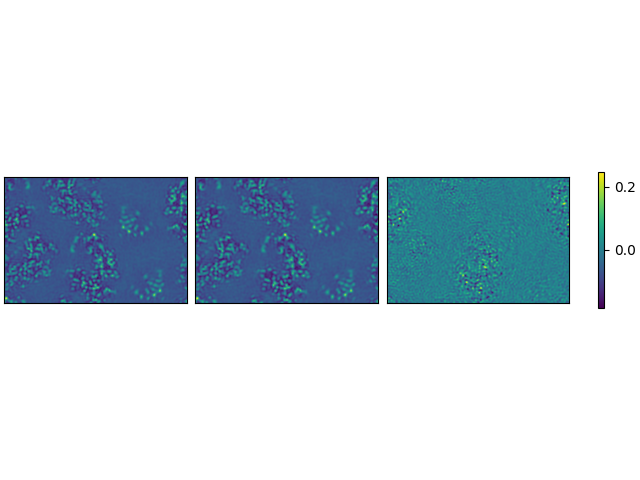

In [8]:
print(    np.abs(np.max(map_dark.to_3d_numpy_map(map_sampling=map_sampling)- map_light.to_3d_numpy_map(map_sampling=map_sampling))))
%matplotlib widget
from plotting3d import panels_3d
_= panels_3d(
    [map_dark.to_3d_numpy_map(map_sampling=map_sampling),
     map_light.to_3d_numpy_map(map_sampling=map_sampling),
    map_dark.to_3d_numpy_map(map_sampling=map_sampling)-
     map_light.to_3d_numpy_map(map_sampling=map_sampling),
    ],
    # imkwargs={"cmap":'bwr', "vmax":.1, "vmin":-.1},
    figkwargs={'nrows':1,'ncols':3}, 
    # axtitles=axtitles
)

## Obtaining diffmaps

In [9]:
from photolyase import loading_diffmaps
diffmaps, diffmap_config = loading_diffmaps(
    map_dark=map_dark,
    map_light=map_light,
    changing_bit=changing_bit,
    map_sampling=map_sampling,
)

Reading from photolyase30ns.mtz


In [10]:
vanilla = diffmaps['vanilla_diffmap'].to_3d_numpy_map(map_sampling=map_sampling)
# pref1 = np.max(vanilla)/np.max(delta_rho_f)
# pref2 = np.min(vanilla)/np.min(delta_rho_f)
# _ = slice_3d(vanilla-delta_rho_f*pref)

### Overview

In [11]:
axtitles = [diffmap_config[key]["title"] for key in diffmaps.keys()]
diffmaps_np = [diffmap.to_3d_numpy_map(map_sampling=map_sampling)
               for diffmap in diffmaps.values()]
# _ = panels_3d(diffmaps_np, imkwargs={"cmap":'bwr', "vmax":.1, "vmin":-.1},figkwargs={'nrows':2,'ncols':2}, axtitles=axtitles)
maxval = 0.01
# _ = panels_3d(diffmaps_np, imkwargs={"cmap":'bwr', "vmax":maxval, "vmin":-maxval},figkwargs={'nrows':2,'ncols':2}, axtitles=axtitles)

# Getting Masks

In [ ]:

     # calculate_dog_filter_mask_v2(,)
                                  
diffmaps['tv'].cell.a

70.2

In [ ]:
diffmap = diffmaps['tv']


In [ ]:
from photolyase import load_mask_config
mask_configs = load_mask_config(
        diffmap,
        map_sampling,
        mask_loc_sphere,
        mask_loc_handcraft
)
masks = load_masks(diffmap,map_sampling, mask_configs)

dogged
0.0006287442985922098 {424: 182, 90: 182, 91: 182, 87: 182, 86: 182, 210: 181, 345: 182, 206: 181, 15: 96, 346: 182, 109: 166, 116: 125, 359: 163, 412: 163, 115: 125, 189: 164, 110: 166, 180: 154, 358: 163, 531: 70, 527: 70, 532: 70, 528: 70}
0.0006702066166326404 {415: 176, 416: 176, 267: 80, 104: 80, 563: 80, 564: 80, 271: 80, 574: 80, 114: 80, 573: 80, 115: 80, 105: 80, 471: 80, 12: 80, 408: 177, 176: 175, 177: 175, 379: 80, 192: 52, 377: 80, 197: 77, 133: 86, 149: 176, 430: 78, 2: 60, 196: 77, 257: 87, 1: 60, 433: 78, 258: 87, 461: 91, 462: 91, 395: 92}


interactive(children=(IntSlider(value=0, description='f0', max=89), Output()), _dom_classes=('widget-interact'…

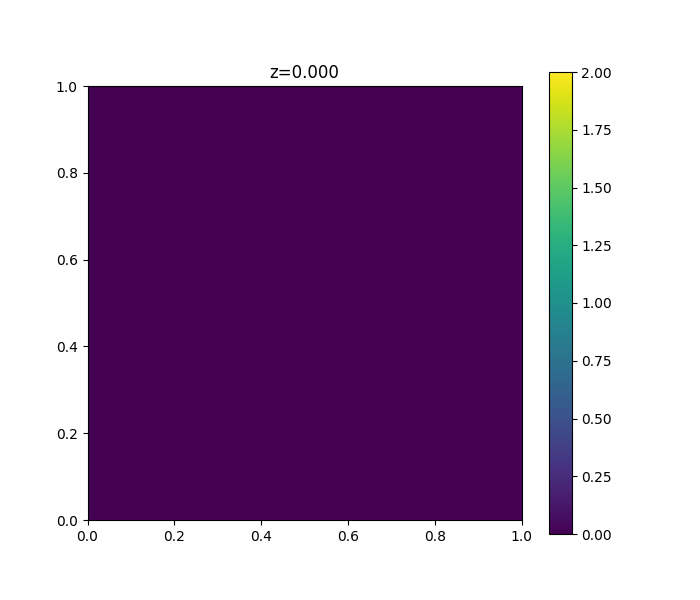

In [15]:
import matplotlib
%matplotlib widget
_ =slice_3d(masks['pseudo-z'], imkwargs={'vmax':2})

In [16]:
np.sum(masks['pseudo-z'])

584

# Calculating rho_xtr


In [17]:
# from plotting3d import *

%matplotlib inline


In [18]:
# Make choices for what to plot 
diffmap_key = 'kweighted' #'tv' 'kweighted' 
mask_key = 'handpicked'

diffmap = diffmaps[diffmap_key]
mask4 = masks[mask_key]
# mask4 = np.logical_and(mask4, diffmap.to_3d_numpy_map(map_sampling=map_sampling)>0)
mask4negsum = np.logical_and(mask4, diffmap.to_3d_numpy_map(map_sampling=map_sampling)<-.01)
# mask4negsum = mask4
diffmap_np = diffmap.to_3d_numpy_map(map_sampling=map_sampling)
mask4hist1 = np.logical_or(diffmap_np>np.max(diffmap_np)/3,diffmap_np<np.min(diffmap_np)/5)
mask_smallest = diffmap_np < np.percentile(diffmap_np, 1)
mask_largest = diffmap_np > np.percentile(diffmap_np, 99)
mask4hist1 = np.logical_or(mask_smallest, mask_largest)
# mask4hist1 = mask4
mask4hist = np.logical_and(mask4, mask4hist1)


if diffmap_key == 'kweighted':
    extrapolation_factors = np.arange(1,100,10)
    extrapolation_factors3 = np.linspace(21.5,49,20)
    extrapolation_factors2 = [5,9,15]
    comb = [extrapolation_factors, extrapolation_factors2, extrapolation_factors3]

elif False:
    extrapolation_factors = np.arange(1,100,10)
    extrapolation_factors3 = np.linspace(63,69,5)
    extrapolation_factors2 = np.linspace(150,600,5)
    comb = [extrapolation_factors, extrapolation_factors2, extrapolation_factors3]
elif True:
    extrapolation_factors = np.linspace(1,100,20)
    comb = [extrapolation_factors,[]]
else:
    extrapolation_factors = np.linspace(1,60,20)
    comb = [extrapolation_factors,[]]

extrapolation_factors = np.sort(np.concatenate(comb))
print(extrapolation_factors)

[ 1.          5.          9.         11.         15.         21.
 21.5        22.94736842 24.39473684 25.84210526 27.28947368 28.73684211
 30.18421053 31.         31.63157895 33.07894737 34.52631579 35.97368421
 37.42105263 38.86842105 40.31578947 41.         41.76315789 43.21052632
 44.65789474 46.10526316 47.55263158 49.         51.         61.
 71.         81.         91.        ]


In [19]:
np.sum(diffmap_np>np.max(diffmap_np)/3), np.sum(diffmap_np<np.min(diffmap_np)/5), diffmap_np.size
np.sum(mask_smallest), np.sum(mask_largest)


(29160, 29159)

In [20]:

diffmaps['tv']

F_tv      PHI_tv
H  K L                      
0  0 1  0.069342  245.467453
     2  0.766619   36.595238
     3  0.256148  251.995697
     4  1.286356  185.724136
     5  0.243945  282.720032
...          ...         ...
29 5 5  1.545872  324.192108
   6 0  0.397404  128.740753
     1  0.267611    293.1922
     2  0.113968  302.602234
     3  0.734945  321.310883

[56156 rows x 2 columns]

In [21]:

rho_xtrs =  make_real_space_xtr(map_dark, diffmap, extrapolation_factors, map_sampling, ) 
map_xtrs = make_k_space_xtr(map_dark, diffmap, extrapolation_factors)

diffmax = (np.max(diffmap.to_3d_numpy_map(map_sampling=map_sampling)))
darkmax = (np.max(map_dark.to_3d_numpy_map(map_sampling=map_sampling)))
print(darkmax,diffmax,darkmax/diffmax)



2.6091971 0.064310804 40.57168


In [22]:
neg_sums = []
neg_sum_real_space = negsum_meteor(rho_xtrs, map_sampling=map_sampling, mask=mask4) 
neg_sum_map = negsum_meteor(map_xtrs, map_sampling=map_sampling, mask=mask4negsum) 

n_largest = 3

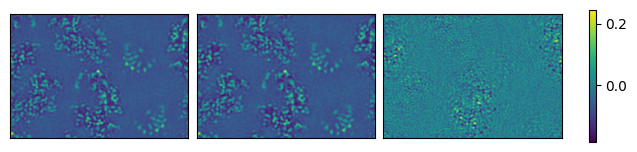

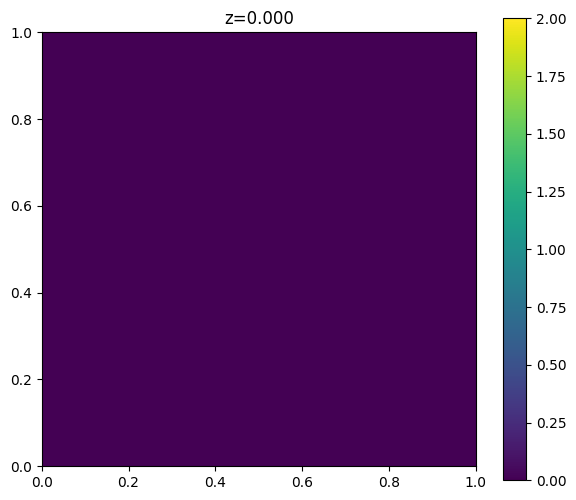

<Figure size 640x480 with 0 Axes>

In [23]:
%matplotlib inline
plt.figure()
plt.show()

In [ ]:

dens_xtrs = [map_xtr.to_3d_numpy_map(map_sampling=map_sampling) for map_xtr in map_xtrs]
rho_dark = map_dark.to_3d_numpy_map(map_sampling=map_sampling)
rmin= np.min(rho_dark)
rmax= np.max(rho_dark)
offset = (rmax-rmin)*0.5
bins = np.linspace(rmin-offset,rmax+offset,100)

dhists, lhists, wdists, bin_centers = get_hists(dens_xtrs, rho_dark, mask4hist, bins)

hist 34.526315789473685
intersection point, 0.077 (25.90)


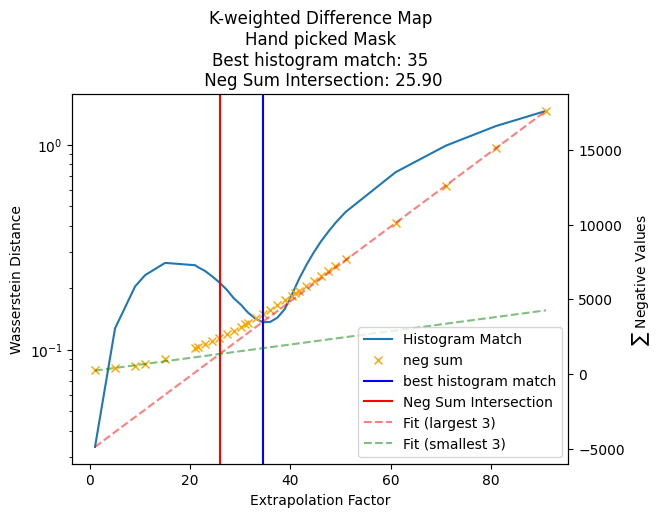

In [25]:
best_values = {}
fig, ax2 = plt.subplots() 
ln1 = ax2.plot(extrapolation_factors, wdists, label="Histogram Match")
# ax2.plot(extrapolation_factors, cross_correl)    


ax = ax2.twinx()
title_str = ""
title_str += diffmap_config[diffmap_key]['title']+'\n'
title_str += mask_configs[mask_key]['title']
# ax.plot(extrapolation_factors, -neg_sum_real_space, 'x')
ax.plot(extrapolation_factors, -neg_sum_map, 'x',color='orange', label='neg sum')

xvalue = find_wasserstein_dip(extrapolation_factors,wdists)
if xvalue:
    print('hist', xvalue)
    best_values['hist']=(xvalue)
    ax.axvline(xvalue, color="blue", label="best histogram match")
    title_str += f"\nBest histogram match: {xvalue:.0f}"  

if n_largest:
    intersect, angle = get_intersect_and_angle(extrapolation_factors, neg_sum_map, n_largest)
    ax.axvline(intersect, color="red", label="Neg Sum Intersection")
    add_fit(neg_sum_map, extrapolation_factors, n_largest, ax=ax)
    best_values['intersect']=(intersect)
    title_str += f"\n Neg Sum Intersection: {intersect:.2f}"  
lns = [ l for l in ax.lines if l.get_label()[0]!="_"]
lns =  ln1 + lns
labs = [l.get_label() for l in lns ]

ax2.set_ylabel('Wasserstein Distance')
ax2.set_xlabel('Extrapolation Factor')
ax2.set_yscale('log')
ax.set_ylabel(r'$\sum$ Negative Values')
# ax.set_xlim(0,60)    
# ax.set_ylim(0,400)    
ax.legend(lns,labs, loc='lower right')
ax.set_title(title_str)
plt.show()

Text(0.5, 0.98, 'K-weighted Difference Map\nHand picked Mask\nBest histogram match: 35')

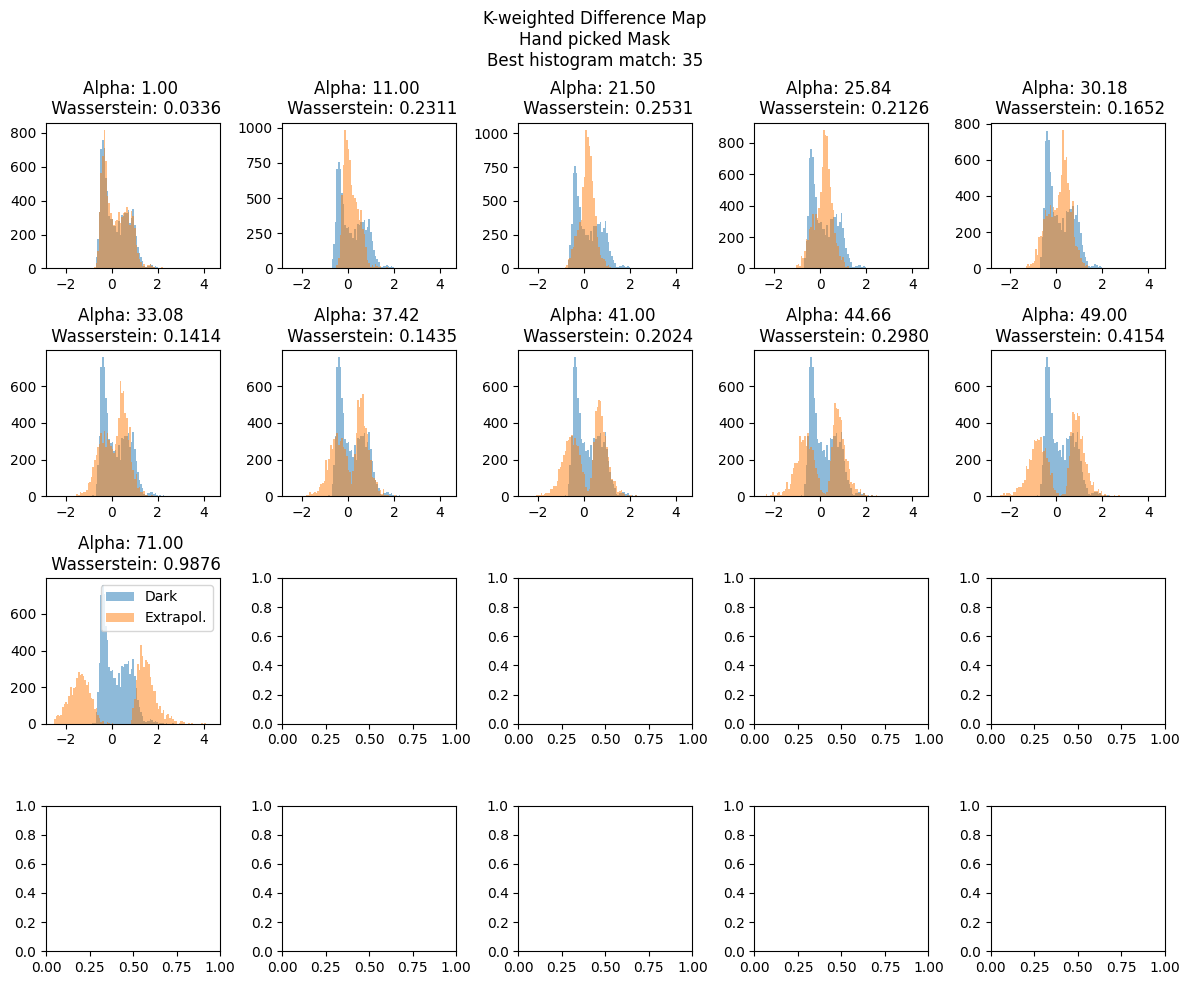

In [26]:

fig,ax1 = plot_hists(dhists[::3], lhists[::3], wdists[::3], bin_centers, extrapolation_factors[::3])
title_str = ""
title_str += diffmap_config[diffmap_key]['title']+'\n'
title_str += mask_configs[mask_key]['title']
title_str += f"\nBest histogram match: {xvalue:.0f}"  
fig.suptitle(title_str)


In [27]:
my_vals = [21,41,71]
map_xtrs_best = make_k_space_xtr(map_dark, diffmap, my_vals)
map_xtrs_best_np = [mapx.to_3d_numpy_map(map_sampling=map_sampling) for mapx in map_xtrs_best]
# print(np.max(map_xtrs_best_np,axis=))
print((np.max(np.asarray(map_xtrs_best_np),axis=(1,2,3))))
panels_3d([density_light_ground-masks['handpicked'].astype(float),*map_xtrs_best_np], figkwargs={'nrows':2,'ncols':2}, imkwargs={'vmin':-1.5,'vmax':1.5, 'cmap':'bwr'})
# for ii,key in enumerate(best_values.keys()):
#     name=f"pl_30ns_diff_{diffmap_key}_mask_{mask_key}_xtr{best_values[key]:.0f}.mtz"
#     print(name)
#     map_xtrs_best[ii].write_mtz(name)

[1.4401762 2.2274895 4.038354 ]


NameError: name 'density_light_ground' is not defined

In [ ]:
map_xtrs_best[1].head() 


F    PHI
H K L                     
0 0 6   3375.962158   -0.0
    8    498.623444 -180.0
    10  1270.667969    0.0
    12  1316.433716 -180.0
    14    729.54126  180.0

In [ ]:
plt.close('all')

In [ ]:
from meteorize import find_largest_blobs
from scipy.ndimage import label, generate_binary_structure

pos_blob_mask, neg_blob_mask = find_largest_blobs(diffmap, map_sampling=map_sampling)
slice_3d(pos_blob_mask-neg_blob_mask)

NameError: name 'generate_binary_structure' is not defined

In [ ]:
density_light_ground.shape
map_xtrs_best[0].shape

(56080, 2)

# Compare with 'Ground Truth'

In [ ]:
# plt.figure()
# 

In [ ]:
def s2r(struc,hs_limit, noise_level):
    map_vals = meteor.sfcalc.gemmi_structure_to_calculated_map(
        struc, high_resolution_limit=hs_limit
    )
    struc_vals = rs.DataSet(map_vals)
    noise = np.random.normal(loc=0.0, scale=noise_level * np.abs(struc_vals["F"]))
    struc_vals["F"] = struc_vals["F"] + noise
    struc_vals["sf"] = struc_vals.to_structurefactor("F", "PHI")
    struc_vals_grid = struc_vals.to_reciprocal_grid("sf")
    struc_vals_real = np.fft.fftn(struc_vals_grid).real/struc_vals_grid.size
    return struc_vals_real

struc_light = gemmi.read_structure(pdbloc_light)
np.max(s2r(struc_light, hs_limit, 0) )

np.float64(1.4131175067909247)

In [ ]:
print(np.max(s2r(struc_light, hs_limit, 0) ))
print(np.max(rho_xtrs[7].to_3d_numpy_map(map_sampling=map_sampling) ))


1.4131175067909247
1.5317982


In [ ]:
import multiprocessing as mp
from skimage.feature import match_template

def match_single(args):
    density_light_ground, rho_xtr, map_sampling = args
    matched = match_template(density_light_ground, rho_xtr.to_3d_numpy_map(map_sampling=map_sampling))
    if matched.size != 1:
        print(matched)
    return matched[0][0]

density_light_ground = s2r(struc_light, hs_limit, 0)

# Prepare arguments for starmap
args_list = [(density_light_ground, rho_xtrs[ii], map_sampling) for ii in range(len(rho_xtrs))]

with mp.Pool(processes=mp.cpu_count()) as pool:
    cross_correl = pool.map(match_single, args_list)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32


In [ ]:
from scipy.signal import correlate
cross_correl_ball = []
mask_type = 'ball'
for ii in range(len(rho_xtrs)):
    xtrs = rho_xtrs[ii].to_3d_numpy_map(map_sampling=map_sampling)
    matched = correlate(density_light_ground[masks[mask_type]] , xtrs[masks[mask_type]], mode='valid')
    norm1 = correlate(density_light_ground[masks[mask_type]] , density_light_ground[masks[mask_type]] , mode='valid')
    norm2 = correlate(xtrs[masks[mask_type]] , xtrs[masks[mask_type]], mode='valid')
    matched = matched/np.sqrt(norm1*norm2)
    if matched.size != 1:
        print(matched)
    cross_correl_ball.append(matched[0])

In [ ]:
from scipy.signal import correlate
mask_type = 'handpicked'
mask_tuned = np.logical_and(masks[mask_type], diffmap>0)
cross_correl_tune = []
for ii in range(len(rho_xtrs)):
    xtrs = rho_xtrs[ii].to_3d_numpy_map(map_sampling=map_sampling)
    matched = correlate(density_light_ground[masks[mask_type]] , xtrs[masks[mask_type]], mode='valid')
    norm1 = correlate(density_light_ground[masks[mask_type]] , density_light_ground[masks[mask_type]] , mode='valid')
    norm2 = correlate(xtrs[masks[mask_type]] , xtrs[masks[mask_type]], mode='valid')
    matched = matched/np.sqrt(norm1*norm2)
    if matched.size != 1:
        print(matched)
    cross_correl_tuned.append(matched[0])


TypeError: object cannot be converted to a MTZFloat32Dtype

In [ ]:
from scipy.signal import correlate
mask_type = 'handpicked'
cross_correl_hand = []
for ii in range(len(rho_xtrs)):
    xtrs = rho_xtrs[ii].to_3d_numpy_map(map_sampling=map_sampling)
    matched = correlate(density_light_ground[masks[mask_type]] , xtrs[masks[mask_type]], mode='valid')
    norm1 = correlate(density_light_ground[masks[mask_type]] , density_light_ground[masks[mask_type]] , mode='valid')
    norm2 = correlate(xtrs[masks[mask_type]] , xtrs[masks[mask_type]], mode='valid')
    matched = matched/np.sqrt(norm1*norm2)
    if matched.size != 1:
        print(matched)
    cross_correl_hand.append(matched[0])

Text(0.5, 0, 'Extrapolation factor')

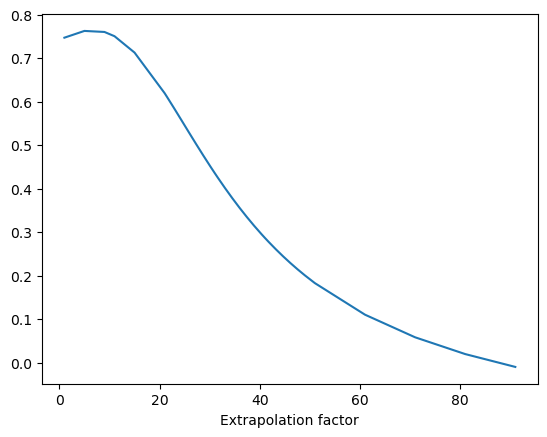

In [ ]:
 
plt.figure()
plt.plot(extrapolation_factors, cross_correl)    
# plt.plot(extrapolation_factors, cross_correl_ball)    
# plt.plot(extrapolation_factors, cross_correl_hand)    
# plt.plot(extrapolation_factors, cross_correl_tuned)    
# plt.xlim(0,30)
plt.xlabel("Extrapolation factor")
# plt.ylim(.74,0.84)
# panels_3d([s2r(struc_light, hs_limit, 0) , rho_xtrs[7].to_3d_numpy_map(map_sampling=map_sampling)])


In [ ]:
extrapolation_factors[np.argmax(cross_correl)]

{'direct_realspace':         F_direct_realspace  PHI_direct_realspace
 H  K L                                          
 0  0 1            0.000051            262.171326
      2            0.000072              6.073973
      3            0.000036            181.241241
      4            0.000039            169.920212
      5            0.000041             87.196999
 ...                    ...                   ...
 29 5 5            0.000033            125.537674
    6 0            0.000009            284.787689
      1            0.000107             76.957405
      2            0.000057            356.153961
      3            0.000099            221.549103
 
 [56156 rows x 2 columns],
 'vanilla_diffmap':         F_vanilla_diffmap  PHI_vanilla_diffmap
 H  K L                                        
 0  0 1                NaN                  NaN
      2                NaN                  NaN
      3                NaN                  NaN
      4                NaN                

In [ ]:
diffmap


F_kweighted  PHI_kweighted
H  K L                            
0  0 1          NaN            NaN
     2          NaN            NaN
     3          NaN            NaN
     4          NaN            NaN
     5          NaN            NaN
...             ...            ...
29 5 5          NaN            NaN
   6 0          NaN            NaN
     1          NaN            NaN
     2          NaN            NaN
     3          NaN            NaN

[56156 rows x 2 columns]

# Attempts at Error Width

(0.0, 200.0)

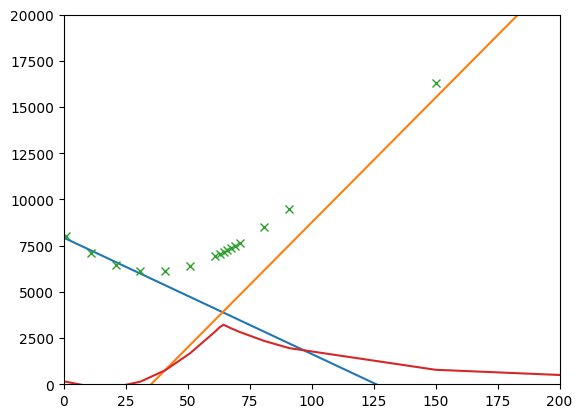

In [ ]:
plt.figure()
neg_sum2 = -neg_sum_map
from occupancy import get_fits
def get_fits2(neg_sum, alpha_invs, n_largest):
    a_sorted = np.argsort(alpha_invs)
    m_lowest = a_sorted <= n_largest
    m_biggest = a_sorted >= len(a_sorted) - n_largest
    res_lowest = stats.linregress(alpha_invs[m_lowest], neg_sum[m_lowest])
    res_biggest = stats.linregress(alpha_invs[m_biggest], neg_sum[m_biggest])
    np.linspace(np.min(alpha_invs), np.max(alpha_invs), 5)
    fit_lowest = res_lowest.intercept + res_lowest.slope * alpha_invs
    fit_biggest = res_biggest.intercept + res_biggest.slope * alpha_invs
    return fit_lowest, fit_biggest
fit_lowest2, fit_biggest2 = get_fits2(neg_sum2,extrapolation_factors, 3)
plt.plot(extrapolation_factors,fit_lowest2)
plt.plot(extrapolation_factors,fit_biggest2)
plt.plot(extrapolation_factors, neg_sum2, 'x', label='neg sum')
diff_low =  -(fit_lowest2-neg_sum2) #is still negative
diff_high = -(fit_biggest2-neg_sum2) #is still negative
plt.plot(extrapolation_factors,np.min([diff_low,diff_high],axis=0))
plt.ylim(0,20_000)
plt.xlim(0,200)
# add_fit(neg_sum_map, extrapolation_factors, n_largest, )
# plt.plot(extrapolation_factors,diff_high)
# plt.plot(alpha_line,fit_lowest)
# plt.plot(extrapolation_factors,diff_high)

(0.0, 4000.0)

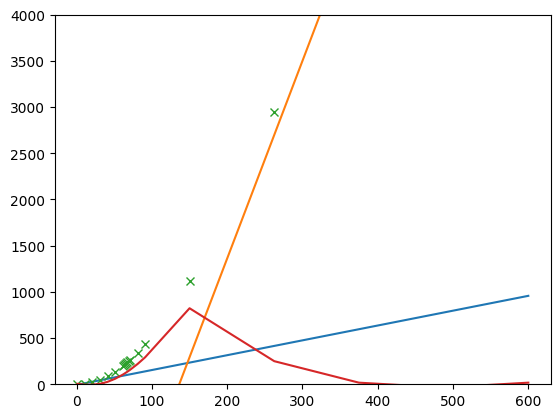

In [ ]:
plt.figure()
neg_sum2 = -neg_sum_map
from occupancy import get_fits
from scipy import stats
def get_fits2(neg_sum, alpha_invs, n_largest):
    a_sorted = np.argsort(alpha_invs)
    m_lowest = a_sorted <= n_largest
    m_biggest = a_sorted >= len(a_sorted) - n_largest
    res_lowest = stats.linregress(alpha_invs[m_lowest], neg_sum[m_lowest])
    res_biggest = stats.linregress(alpha_invs[m_biggest], neg_sum[m_biggest])
    np.linspace(np.min(alpha_invs), np.max(alpha_invs), 5)
    fit_lowest = res_lowest.intercept + res_lowest.slope * alpha_invs
    fit_biggest = res_biggest.intercept + res_biggest.slope * alpha_invs
    return fit_lowest, fit_biggest
fit_lowest2, fit_biggest2 = get_fits2(neg_sum2,extrapolation_factors, 3)
plt.plot(extrapolation_factors,fit_lowest2)
plt.plot(extrapolation_factors,fit_biggest2)
plt.plot(extrapolation_factors, neg_sum2, 'x', label='neg sum')
diff_low =  -(fit_lowest2-neg_sum2) #is still negative
diff_high = -(fit_biggest2-neg_sum2) #is still negative
div_low =  -(fit_lowest2-neg_sum2)/fit_lowest2 #is still negative
div_high = -(fit_biggest2-neg_sum2)/fit_biggest2 #is still negative
smaller_diff = np.min([diff_low,diff_high],axis=0)
smaller_div = np.min([div_low,div_high],axis=0)
plt.plot(extrapolation_factors,smaller_diff)
plt.ylim(0,4_000)
# plt.xlim(0,200)
# add_fit(neg_sum_map, extrapolation_factors, n_largest, )
# plt.plot(extrapolation_factors,diff_high)
# plt.plot(alpha_line,fit_lowest)
# plt.plot(extrapolation_factors,diff_high)


In [ ]:
plt.plot(smaller_div

array([-1.01312421e+00, -1.00242454e+00, -1.00908549e+00, -1.02145017e+00,
       -1.04203085e+00, -1.07388800e+00, -1.12080986e+00, -1.13262833e+00,
       -1.14201740e+00, -1.15191352e+00, -1.16237808e+00, -1.17346333e+00,
       -1.18938329e+00, -1.29066943e+00, -1.44593651e+00,  2.80908911e+00,
        9.26719692e-02,  3.42861655e-03, -4.66065377e-03,  1.76495755e-03])